
 Data Preprocessing & EDA

- Loaded datasets (mhqa.csv and mhqa-b.csv)
- Performed data cleaning by handling missing values and removing duplicates
- Validated and transformed labels (converted to 0-based indexing)
- Created additional features such as question length and option length
- Conducted Exploratory Data Analysis (EDA)
- Generated visualizations including:
  • Question type distribution
  • Topic distribution
  • Correct option distribution
  • Category distribution

Dataset Preparation & Tokenization

- Implemented custom PyTorch Dataset class (MCQADataset)
- Converted question and options into model input format
- Applied BERT tokenizer for text processing
- Prepared input tensors (input_ids, attention_mask)
- Created DataLoaders for training and testing

 Model Training & Evaluation
- Loaded pre-trained BERT model (bert-base-uncased)
- Fine-tuned the model on the mhqa-b dataset
- Implemented training loop with optimizer and learning rate scheduler
- Evaluated model performance on mhqa test dataset
- Calculated accuracy and analyzed results
- Generated sample predictions for validation
- Saved the best-performing model

The project follows a complete pipeline:
Data Preprocessing → EDA → Dataset Preparation → Model Training → Evaluation


Install libraries

In [ ]:
# Install required libraries (run once)
!pip install transformers torch scikit-learn pandas matplotlib seaborn tqdm -q


Step 2 – Upload Dataset


In [ ]:
from google.colab import files
print("Upload mhqa-b.csv and mhqa.csv")
uploaded = files.upload()

Upload mhqa-b.csv and mhqa.csv


Saving mhqa-b.csv to mhqa-b.csv
Saving mhqa.csv to mhqa.csv


Step 3 – Check GPU

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


Step 4 – Imports & Config

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

from sklearn.metrics import classification_report, confusion_matrix

# CONFIG
TRAIN_PATH = "mhqa-b.csv"
TEST_PATH  = "mhqa.csv"

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 2
LR = 2e-5

LABEL2ID = {"Diagnostic": 0, "Factoid": 1, "Preventive": 2, "Prognostic": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Step 5 – Load & Preprocess Data

In [ ]:
def load_and_clean(path):
    df = pd.read_csv(path)[["question", "type"]].copy()
    df.dropna(inplace=True)
    df.drop_duplicates(subset=["question"], inplace=True)
    df = df[df["type"].isin(LABEL2ID.keys())]
    df["label"] = df["type"].map(LABEL2ID)
    df.reset_index(drop=True, inplace=True)
    return df

df_train = load_and_clean(TRAIN_PATH)
df_test  = load_and_clean(TEST_PATH)

print("Train size:", len(df_train))
print("Test size:", len(df_test))
print(df_train["type"].value_counts())

Train size: 56142
Test size: 2474
type
Diagnostic    18557
Preventive    16915
Prognostic    12591
Factoid        8079
Name: count, dtype: int64


Step 6 – EDA (Simple Plot)

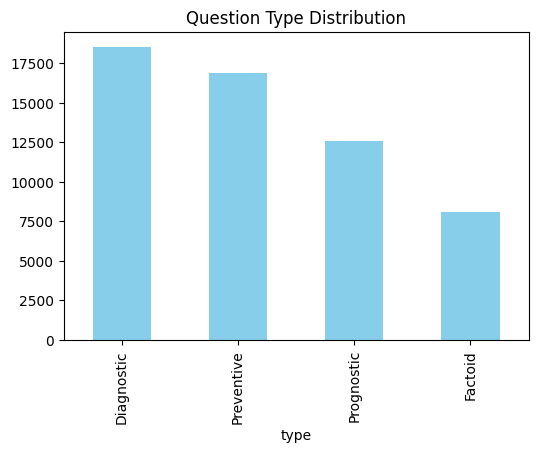

In [ ]:
plt.figure(figsize=(6,4))
df_train["type"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Question Type Distribution")
plt.show()

CELL 7 – Dataset Class

In [ ]:
class QuestionDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row["question"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

CELL 8 – Tokenizer & Model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CELL 9 – DataLoaders

In [ ]:
train_loader = DataLoader(QuestionDataset(df_train, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(QuestionDataset(df_test, tokenizer),
                         batch_size=BATCH_SIZE)

CELL 10 – Optimizer & Scheduler

In [ ]:
optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

CELL 11 – Training Function

In [ ]:
def train_epoch():
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

CELL 12 – Evaluation Function

In [ ]:
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            logits = outputs.logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["label"].numpy())

    return preds, labels

CELL 13 – Training Loop

In [ ]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")
    loss = train_epoch()
    print("Loss:", loss)


Epoch 1


100%|██████████| 7018/7018 [24:12<00:00,  4.83it/s]


Loss: 0.6567622196549285

Epoch 2


100%|██████████| 7018/7018 [24:13<00:00,  4.83it/s]

Loss: 0.4955666288146927


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# History storage
history = {
    "train_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # =========================
    # TRAINING
    # =========================
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # =========================
    # EVALUATION
    # =========================
    model.eval()
    preds, true_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            logits = outputs.logits

            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(true_labels, preds)

    # =========================
    #  STORE HISTORY
    # =========================
    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/2


Evaluating: 100%|██████████| 310/310 [00:19<00:00, 15.82it/s]


Train Loss: 0.4224
Validation Accuracy: 0.7987

Epoch 2/2


Evaluating: 100%|██████████| 310/310 [00:19<00:00, 15.85it/s]

Train Loss: 0.4228
Validation Accuracy: 0.7987


CELL 14 – Final Evaluation

In [ ]:
preds, labels = evaluate(test_loader)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(labels, preds))
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=LABEL2ID.keys()))

Test Accuracy: 0.7987065481002426

Classification Report:
              precision    recall  f1-score   support

  Diagnostic       0.76      0.84      0.80       878
     Factoid       0.68      0.63      0.65       324
  Preventive       0.88      0.84      0.86       714
  Prognostic       0.84      0.77      0.80       558

    accuracy                           0.80      2474
   macro avg       0.79      0.77      0.78      2474
weighted avg       0.80      0.80      0.80      2474



CELL 15 – Confusion Matrix

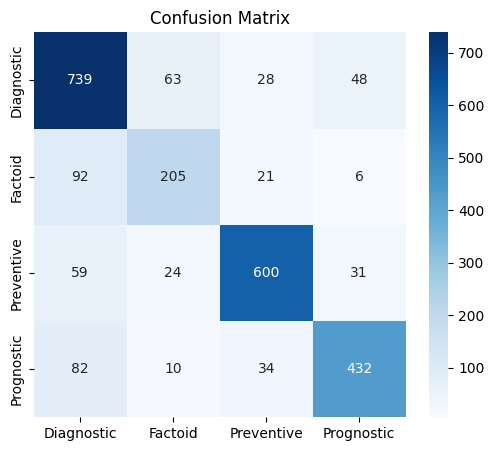

In [ ]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL2ID.keys(),
            yticklabels=LABEL2ID.keys())
plt.title("Confusion Matrix")
plt.show()

CELL 16 – Accuracy per Class (Bar Chart)

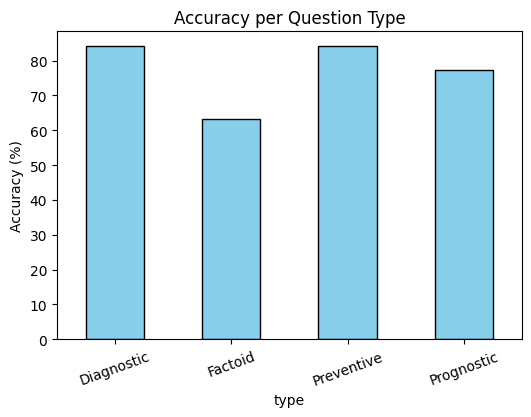

In [ ]:
import pandas as pd

# Per-class accuracy
df_test["pred"] = preds
df_test["correct"] = (df_test["pred"] == df_test["label"])

class_acc = df_test.groupby("type")["correct"].mean() * 100

plt.figure(figsize=(6,4))
class_acc.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Accuracy per Question Type")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.show()

CELL 17 – Prediction Distribution

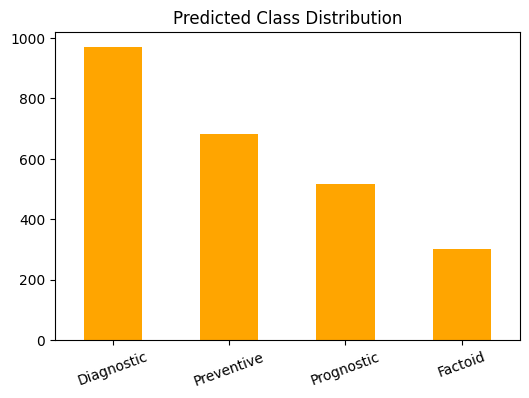

In [ ]:
pred_types = [ID2LABEL[p] for p in preds]

plt.figure(figsize=(6,4))
pd.Series(pred_types).value_counts().plot(kind="bar", color="orange")
plt.title("Predicted Class Distribution")
plt.xticks(rotation=20)
plt.show()

CELL 18 – Sample Predictions

In [ ]:
print("="*70)
print("SAMPLE PREDICTIONS (5 EXAMPLES)")
print("="*70)

for i in range(5):
    row = df_test.iloc[i]

    pred_label = ID2LABEL[preds[i]]
    true_label = row["type"]

    status = "✓ CORRECT" if pred_label == true_label else "✗ WRONG"

    print(f"\n[{status}]")
    print(f"Question : {row['question'][:100]}...")
    print(f"True     : {true_label}")
    print(f"Predicted: {pred_label}")

SAMPLE PREDICTIONS (5 EXAMPLES)

[✗ WRONG]
Question : Which subgroup reported lower perceived social support when compared to adjustment disorder patients...
True     : Diagnostic
Predicted: Factoid

[✓ CORRECT]
Question : Which group of patients exhibited lower levels of whole blood serotonin compared to healthy voluntee...
True     : Factoid
Predicted: Factoid

[✓ CORRECT]
Question : How does the overexpression of the Slc1a1 gene in forebrain neurons potentially influence the respon...
True     : Prognostic
Predicted: Prognostic

[✓ CORRECT]
Question : What treatment was shown to gradually decrease stereotypic behaviors in captive primates, which are ...
True     : Preventive
Predicted: Preventive

[✗ WRONG]
Question : How does maternal obsessive-compulsive disorder during pregnancy potentially affect fetal brain deve...
True     : Preventive
Predicted: Prognostic


CELL 19 – Training Curve

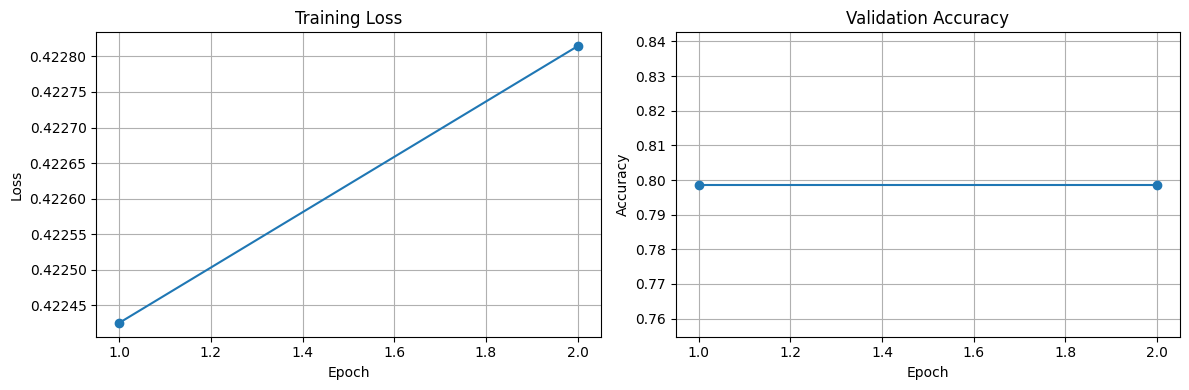

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#  Loss
ax1.plot(epochs, history["train_loss"], marker='o')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

#  Accuracy
ax2.plot(epochs, history["val_acc"], marker='o')
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()